# Physical Constants

This notebook defines the fundamental physical constants used in the analytic implementation of the Bethe-Bloch equation. All values are sourced from authoritative references:

- **[CODATA 2022](https://physics.nist.gov/cuu/Constants/index.html)** — Committee on Data for Science and Technology
- **[PDG 2024](https://pdg.lbl.gov/2026/html/computer_read.html)** — Particle Data Group

These constants are consistent with the theoretical derivation presented in *Bethe_Full_Derivation.pdf* (report directory).

## Scope

These constants are specifically designed to support the **non-relativistic Bethe formula** in its pure form, *without* shell corrections, Barkas effects, Bloch corrections, or density effects. For complete details on the theoretical framework and project scope, refer to *Bethe_Full_Derivation.pdf* and the full project report (TO DO).


In [1]:
#   Electron rest mass energy m_e*c^2 in MeV (CODATA, 2022)
ELECTRON_MASS_MEV = 0.51099895069

#   Proton rest mass energy m_e*c^2 in MeV (CODATA, 2022)
PROTON_MASS_MEV = 938.27208943

#   PDG's K constant: K = 4*pi*N_A*r_e^2*m_e^2, en MeV*cm^2/mol
#   (previously verified against own theoretical derivation, Sect. 2.6 of
#   Bethe_Full_Derivation.pdf file in the report directory, coinciding
#   with PDF 2024 Sect 34.2.1)
K_MEV_CM2_PER_MOL = 0.307075

#   Conversion factor eV -> MeV
EV_TO_MEV = 1e-6

## Material Properties

This section defines the properties of the four absorber materials used throughout the project.

### Data Sources and Verification

All material parameters—**atomic number (Z)**, **atomic mass (A)**, **mean excitation energy (I)**, and **density (ρ)**—have been carefully verified against authoritative references:

- [**NIST STAR Composition Database**](https://www.nist.gov/cgi-bin/Star/compos.pl)
- [**NIST Periodic Table (June 2024)**](www.nist.gov/system/files/documents/2024/06/25/NIST_periodictable_June24_iupac.pdf)

Each material corresponds to a specific NIST material number (`matno`) that matches the reference data downloaded in the `nist_data` directory.

### Rationale for NIST Parameter Adoption

The values of **I** and **density** are deliberately taken from NIST PSTAR to ensure that any discrepancies between:
- Our theoretical predictions (pure Bethe formula)
- NIST PSTAR reference data

can be attributed **solely** to the omitted corrections (shell, Barkas, Bloch, density effects) rather than differences in material property definitions.

### Treatment of Compounds: Water

For **water** (H₂O), being a compound rather than a pure element, the effective Z/A ratio is calculated using the **Bragg additivity rule**:

$$\left(\frac{Z}{A}\right)_{\text{eff}} = \sum_i w_i \left(\frac{Z_i}{A_i}\right)$$

where $w_i$ is the mass fraction of *i-th* constituent element.

This is the standard approach for compounds and mixtures in stopping power calculations, as documented in **ICRU 37** and **ICRU 49** (Sect. 2.5.2 Eq. 2.22).


In [2]:
from dataclasses import dataclass

@dataclass(frozen=True)
class Material:
    name: str
    Z_over_A: float       #   Effective Z/A [mol/g]
    I_eV: float            #   Mean excitation energy [eV]
    Delta_I_eV: float       #   Uncertainty on I [eV] (source: see table below)
    rho_g_cm3: float        #   Density [g/cm^3]
    Delta_rho_g_cm3: float   #   Uncertainty on density [g/cm^3] (ASSUMED 0.5%,
                             #   see note below -- no source located for solids)
    A_g_mol: float           #   Standard atomic weight [g/mol] (None for water,
                             #   a compound -- see WATER_H/WATER_O constants below)
    Delta_A_g_mol: float      #   Uncertainty on A [g/mol] (None for water)
    matno: str                #   NIST STAR material number (for traceability)

#   ------------------------------------------------------------------
#   Mean excitation energies I and their uncertainties:
#     Water:     ICRU Report 90 (2016), Sec. 5.3 "Mean Excitation Energy
#                of Liquid Water" -- recommended value 78(2) eV.
#     Al/Cu/Pb:  ICRU Report 49 (1993), Table 2.8, Sec. 2.5.1 "Mean
#                Excitation Energies for Elements".
#
#   Standard atomic weights A and their uncertainties:
#     IUPAC/CIAAW, Table 2 "List of Elements in Atomic Number Order"
#     (https://iupac.qmul.ac.uk/AtWt/), 2021 recommended values.
#     NOTE: Pb's standard atomic weight is 207.2(1.1) g/mol -- the
#     parenthetical uncertainty is +/-1.1, NOT +/-0.1. This reflects
#     genuine natural isotopic variability (Pb's standard atomic weight
#     was changed to an interval, [206.14, 207.94], in the 2021 IUPAC
#     revision); 207.2(1.1) is IUPAC's own conservative symmetric
#     value chosen to cover that full interval.
#
#   Densities and their uncertainties:
#     PubChem Periodic Table (https://pubchem.ncbi.nlm.nih.gov/ptable/density/).
#     PubChem does not publish a density uncertainty; a representative
#     0.5% "engineering-grade" tolerance is ASSUMED for all four
#     materials (no uncertainty source was located for solid/liquid
#     densities in the literature consulted).
#   ------------------------------------------------------------------

ALUMINIUM = Material(
    name="ALUMINIUM",
    Z_over_A=13.0 / 26.9815384,
    I_eV=166.0, Delta_I_eV=2.0,          # ICRU 49, Table 2.8
    rho_g_cm3=2.70, Delta_rho_g_cm3=2.70 * 0.005,   # PubChem; 0.5% ASSUMED
    A_g_mol=26.9815384, Delta_A_g_mol=0.0000003,     # IUPAC: 26.981 5384(3)
    matno="013",
)

COPPER = Material(
    name="COPPER",
    Z_over_A=29.0 / 63.546,
    I_eV=322.0, Delta_I_eV=10.0,          # ICRU 49, Table 2.8
    rho_g_cm3=8.96, Delta_rho_g_cm3=8.96 * 0.005,    # PubChem; 0.5% ASSUMED
    A_g_mol=63.546, Delta_A_g_mol=0.003,               # IUPAC: 63.546(3)
    matno="029",
)

LEAD = Material(
    name="LEAD",
    Z_over_A=82.0 / 207.2,
    I_eV=823.0, Delta_I_eV=30.0,          # ICRU 49, Table 2.8
    rho_g_cm3=11.34, Delta_rho_g_cm3=11.34 * 0.005,  # PubChem; 0.5% ASSUMED
    A_g_mol=207.2, Delta_A_g_mol=1.1,                  # IUPAC: 207.2(1.1) --
                                                        # NOTE the large
                                                        # uncertainty, see note above
    matno="082",
)

#   Liquid water: compound, Z/A by the Bragg rule. Composition by mass
#   fraction (NIST Star, matno = 276): H w=0.111894, O w=0.888106.
#   Atomic weights (IUPAC Table 2): H = 1.0080(2), O = 15.999(1).
WATER_A_H, WATER_DELTA_A_H = 1.0080, 0.0002     # IUPAC: H = 1.0080(2)
WATER_A_O, WATER_DELTA_A_O = 15.999, 0.001      # IUPAC: O = 15.999(1)
WATER_W_H, WATER_W_O = 0.111894, 0.888106        # NIST STAR mass fractions
WATER_Z_H, WATER_Z_O = 1, 8

WATER_Z_OVER_A = (WATER_W_H * (WATER_Z_H / WATER_A_H)
                   + WATER_W_O * (WATER_Z_O / WATER_A_O))

WATER = Material(
    name="WATER",
    Z_over_A=WATER_Z_OVER_A,
    I_eV=78.0, Delta_I_eV=2.0,             # ICRU 90 (2016), Sec. 5.3
    rho_g_cm3=1.0, Delta_rho_g_cm3=1.0 * 0.005,   # PubChem; 0.5% ASSUMED
    A_g_mol=None, Delta_A_g_mol=None,       # compound -- see WATER_A_H/A_O above
    matno="276",
)

#   Iteration-friendly dictionary
MATERIALS = {
    "water": WATER,
    "aluminium": ALUMINIUM,
    "copper": COPPER,
    "lead": LEAD,
}


if __name__ == "__main__":
    #   Quick sanity check: water's Z/A should give ~ 0.55509 (See
    #   "Atomic and nuclear properties" from PDG)
    for key, mat in MATERIALS.items():
        A_str = f"{mat.A_g_mol}" if mat.A_g_mol is not None else "compound (H/O)"
        print(f"{mat.name:12s} Z/A={mat.Z_over_A:.6f}  I={mat.I_eV:.1f}({mat.Delta_I_eV:.1f}) eV  "
              f"rho={mat.rho_g_cm3:.4f}({mat.Delta_rho_g_cm3:.4f}) g/cm^3  A={A_str}  (matno={mat.matno})")

WATER        Z/A=0.555087  I=78.0(2.0) eV  rho=1.0000(0.0050) g/cm^3  A=compound (H/O)  (matno=276)
ALUMINIUM    Z/A=0.481811  I=166.0(2.0) eV  rho=2.7000(0.0135) g/cm^3  A=26.9815384  (matno=013)
COPPER       Z/A=0.456362  I=322.0(10.0) eV  rho=8.9600(0.0448) g/cm^3  A=63.546  (matno=029)
LEAD         Z/A=0.395753  I=823.0(30.0) eV  rho=11.3400(0.0567) g/cm^3  A=207.2  (matno=082)


# Analytical Bethe-Bloch Implementation

## Overview

This module implements the **relativistic Bethe-Bloch equation** for protons in its pure form, deliberately excluding shell corrections, Barkas effects, Bloch corrections, and density effects.

## Theoretical Foundation

The implementation corresponds exactly to the equation presented in the **"Relativistic Bethe"** section of the theoretical derivation document (see *Bethe_Full_Derivation.pdf* in the report directory), specifically the subsection *"Distribution of the relativistic correction and assembled result"*.

### Fundamental Equation

The linear stopping power in its basic form:

$$-\frac{dE}{dx} = \frac{4\pi z^2 e^4 n_a Z}{m_e c^2 \beta^2} \left[\ln\left(\frac{2m_e c^2 \beta^2 \gamma^2}{I}\right) - \beta^2\right]$$

### Mass Stopping Power Form

Rewritten in the standard **mass stopping power** convention [MeV·cm²/g] used by PDG and NIST PSTAR:

$$S(T) = -\frac{1}{\rho}\frac{dE}{dx} = K \cdot z^2 \cdot \frac{Z}{A} \cdot \frac{1}{\beta^2} \left[\ln\left(\frac{2m_e c^2 \beta^2 \gamma^2}{I}\right) - \beta^2\right]$$

where $K = 4\pi N_A r_e^2 m_e c^2$ (see constants defined above).

---

## ⚠️ Important Scope and Limitations

### **Deliberately Excluded Corrections**

This implementation **does NOT include**:

- **Shell correction** (C/Z term)
- **Barkas correction** (z³ term)
- **Bloch correction** (z², beyond Born approximation)
- **Density effect** (Sternheimer δ(βγ) correction)

### **Physical Justification**

These corrections are deliberately omitted for well-documented physical reasons (see *"Project Scope and Future Work"* section in the theoretical derivation document).

### **Expected Behavior**

⚠️ **Consequence**: This function will systematically **underestimate** the stopping power reported by:
- NIST PSTAR database
- Geant4 simulations

The discrepancy increases for:
- **Low energies** (< 10 MeV)
- **High-Z materials** (e.g., lead)

### **This is NOT a bug** — it is an **expected and documented result** of the project scope.

---

## Validity Range

This implementation is valid in the **Born approximation** regime, characterized by the Sommerfeld parameter:

$$\eta = \frac{z\alpha}{\beta} \ll 1$$

For **protons** in the energy range **3–300 MeV**:
- η ranges from ~0.011 to ~0.09

See section *"Validity criterion: the Sommerfeld parameter"* in the derivation document for detailed discussion.


In [3]:
import numpy as np

def beta_gamma_from_kinetic_energy(T_MeV, particle_mass_MeV=PROTON_MASS_MEV):
    """
    Calculate relativistic beta and gamma factors from the kinetic energy
    T (in MeV) of a particle at a rest mass energy equivalent particle_mass_MeV,
    which is taken to be that of the proton by default.

    The used formulas are

    gamma = 1 + T / (Mc^2)
    beta = sqrt(1 - 1/gamma^2)

    Parameters
    ----------
    :param T_MeV: Kinetic energy in MeV (array-like)
    :param particle_mass_MeV: Particle mass in MeV (float)

    Returns
    -------
    :return: Tuple (beta, gamma)
    """
    T_MeV = np.asarray(T_MeV, dtype=float)
    gamma = 1.0 + T_MeV / particle_mass_MeV
    beta = np.sqrt(1.0 - 1.0 / gamma**2)
    return beta, gamma

def mass_stopping_power(T_MeV, material: Material, z=1, particle_mass_MeV=PROTON_MASS_MEV):
    """"
    Parameters
    ----------
    :param T_MeV: Kinetic energy in MeV (array-like)
    :param material: Absorber material (See defined materials above)
    :param z: Projectile charge in e units,
                taken as 1 for protons by default (see below) (float)
    :param particle_mass_MeV: Particle mass in MeV (float)

    Returns
    -------
    :return: S: Mass stopping power in MeV cm^2/g (np.ndarray)
    """
    T_MeV = np.asarray(T_MeV, dtype=float)
    beta, gamma = beta_gamma_from_kinetic_energy(T_MeV, particle_mass_MeV)

    I_MeV = material.I_eV * EV_TO_MEV

    #   Calculation of the logarithm argument
    log_arg = (2.0 * ELECTRON_MASS_MEV * beta**2 * gamma**2) / I_MeV

    main_bracket = np.log(log_arg) - beta**2

    S = K_MEV_CM2_PER_MOL * z**2 * material.Z_over_A * main_bracket / beta**2

    return S

def linear_stopping_power(T_MeV, material: Material, z=1, particle_mass_MeV=PROTON_MASS_MEV):
    """
    Linear stopping power -(dE/dx) in MeV/cm, for a particle
    with kinetic energy T_MeV in MeV in `material`. This is
    simply the mass stopping power times the material density.
    """
    S_mass = mass_stopping_power(T_MeV, material, z, particle_mass_MeV)
    return S_mass * material.rho_g_cm3

def validity_check(T_MeV, particle_mass_MeV=PROTON_MASS_MEV):
    """
    Returns a dictionary with beta, gamma, beta*gamma, and a Boolean flag
    indicating whether the point is within the validity range of
    the Bethe formula WITHOUT corrections (beta*gamma >= 0.1, i.e.,
    T >= 4.68 MeV for protons). See Sec. "Project Scope and
    Future Work" of the derivation document.
    """
    beta, gamma = beta_gamma_from_kinetic_energy(T_MeV, particle_mass_MeV)
    bg = beta * gamma
    return{
        "beta": beta,
        "gamma": gamma,
        "beta_gamma": bg,
        "valid_uncorrected_bethe": bg >= 0.1,
    }

if __name__ == "__main__":
    #   Sanity check: 100 MeV proton in water
    T_test = 100.0
    S = mass_stopping_power(T_test, WATER)
    vc = validity_check(T_test)
    print(f"Proton {T_test} MeV in water:")
    print(f"    beta = {vc['beta']:.5f}, gamma = {vc['gamma']:.5f}, "
          f"    beta*gamma = {vc['beta_gamma']:.4f}")
    print(f"    S (no corrections) = {S:.4f} [MeV cm^2/g]")
    print(f"NIST PSTAR Reference Value (with corrections) ~ 7.289,")
    print("see 'pstar_water.csv' file for comparison with NIST PSTAR values.")
    dif_porc = (np.abs(S - 7.289) / 7.289) * 100
    print(f"Difference from NIST PSTAR value: {dif_porc:.2f}%")
    if dif_porc < 2:
        print("Within 2% of NIST PSTAR value.")
    else:
        print("Over 2% of NIST PSTAR value.")


Proton 100.0 MeV in water:
    beta = 0.42820, gamma = 1.10658,     beta*gamma = 0.4738
    S (no corrections) = 7.2545 [MeV cm^2/g]
NIST PSTAR Reference Value (with corrections) ~ 7.289,
see 'pstar_water.csv' file for comparison with NIST PSTAR values.
Difference from NIST PSTAR value: 0.47%
Within 2% of NIST PSTAR value.


## Basic tests

The following suite of unit tests rigorously validates the core analytical functions of this module. **`test_beta_gamma_limits`** verifies the correct asymptotic relativistic behaviour of `beta_gamma_from_kinetic_energy`, ensuring γ → 1 at near-zero energies and γ = 2 exactly at *T* = *Mc*². **`test_stopping_power_positive_and_finite`** confirms that `mass_stopping_power` returns physically meaningful (positive, finite) values across the full clinical energy range for all four absorber materials. **`test_stopping_power_decreasing_with_energy_in_clinical_range`** asserts the expected monotonic decrease of *S*(*T*) with energy in the 3–300 MeV window, where the 1/β² dominance over the logarithmic relativistic argument governs the curve's shape. **`test_water_100mev_matches_nist_within_1pct`** provides a quantitative cross-check against the NIST PSTAR reference value of 7.289 MeV·cm²/g at 100 MeV in water — a particularly clean benchmark since shell corrections are nearly negligible there. **`test_linear_stopping_power_scales_with_density`** ensures self-consistency between `mass_stopping_power` and `linear_stopping_power` by verifying the ρ-scaling identity. **`test_charge_scaling`** enforces the fundamental *z*² dependence of the Bethe formula. Finally, **`test_validity_flag_at_clinical_lower_bound`** probes the `validity_check` function at the boundaries of the clinical range, flagging the well-documented region of highest theoretical uncertainty near the Bragg peak.


In [4]:
def test_beta_gamma_limits():
    #   As T -> 0 should give beta -> 0
    beta, gamma = beta_gamma_from_kinetic_energy(1e-6)  #   1 [eV]
    assert beta < 1e-3
    assert np.isclose(gamma, 1.0, atol=1e-6)

    #   T = Mc^2 -> gamma = 2
    beta, gamma = beta_gamma_from_kinetic_energy(PROTON_MASS_MEV)
    assert np.isclose(gamma, 2.0, atol=1e-6)
    assert beta < 1.0

def test_stopping_power_positive_and_finite():
    energies = np.array([3.0, 10.0, 62.3, 100.0, 200.0, 300.0])
    for mat in (WATER, ALUMINIUM, COPPER, LEAD):
        S = mass_stopping_power(energies, mat)
        assert np.all(np.isfinite(S))
        assert np.all(S > 0)

def test_stopping_power_decreasing_with_energy_in_clinical_range():
    #   In the 3-300 MeV range (over the ionization minima),
    #   dE/dx should be monotonously decreasing as the energy increases
    #   as '-1/beta^2' dominates over the logarithm with the relativistic
    #   argument increases in this range.
    energies = np.linspace(3.0, 300.0, 50)
    S = mass_stopping_power(energies, WATER)
    assert np.all(np.diff(S) < 0), "S(T) should be monotonously decreasing as the energy increases"

def test_water_100mev_matches_nist_within_1pct():
    #   Sanity check against NIST PSTAR value (7.289 [MeV cm^2/g],
    #   again, see 'pstar_water.csv' file in the nist_data directory).
    #   A 1% difference is allowed since, for water, the shell correction
    #   is nearly negligible in the considered energy range.
    S = mass_stopping_power(100.0, WATER)
    nist_reference = 7.289
    rel_diff = abs(S - nist_reference) / nist_reference
    assert rel_diff < 0.01, f"Difference {rel_diff:.4f}% exceeds expected 1%"

def test_linear_stopping_power_scales_with_density():
    T = 100.0
    S_mass = mass_stopping_power(T, LEAD)
    S_linear = linear_stopping_power(T, LEAD)
    assert np.isclose(S_linear, S_mass * LEAD.rho_g_cm3)

def test_charge_scaling():
    #   Stopping power should scale as z^2
    #   (testing with z=2, α-like)
    T = 100.0
    S_z1 = mass_stopping_power(T, WATER, z=1)
    S_z2 = mass_stopping_power(T, WATER, z=2)
    assert np.isclose(S_z2, 4 * S_z1, rtol=1e-10)

def test_validity_flag_at_clinical_lower_bound():
    #   The lower bound of the clinical range (3 MeV) should
    #   be close or under the validity threshold:
    #   beta * gamma >= 0.1
    vc_3mev = validity_check(3.0)
    vc_300mev = validity_check(300.0)
    assert vc_300mev["valid_uncorrected_bethe"]
    #   At 3 MeV it is expected for beta*gamma to be lower
    #   than at higher energies, although the exact result
    #   (wether it is valid or not) is left as informative,
    #   not as a strict assertion, since it is the point of
    #   highest documented uncertainty in the whole project.
    print(f"beta*gamma a 3 MeV: {vc_3mev['beta_gamma']:.4f} "
          f"(umbral de validez sin correcciones: 0.1")

def _run_all():
    tests = [
        test_beta_gamma_limits,
        test_stopping_power_positive_and_finite,
        test_stopping_power_decreasing_with_energy_in_clinical_range,
        test_water_100mev_matches_nist_within_1pct,
        test_linear_stopping_power_scales_with_density,
        test_charge_scaling,
        test_validity_flag_at_clinical_lower_bound,
    ]
    n_ok = 0
    for t in tests:
        try:
            t()
            print(f"OK  {t.__name__}")
            n_ok += 1
        except AssertionError as e:
            print(f"FAIL {t.__name__}: {e}")
    print(f"{n_ok}/{len(tests)} tests passed")

if __name__ == "__main__":
    _run_all()


OK  test_beta_gamma_limits
OK  test_stopping_power_positive_and_finite
OK  test_stopping_power_decreasing_with_energy_in_clinical_range
OK  test_water_100mev_matches_nist_within_1pct
OK  test_linear_stopping_power_scales_with_density
OK  test_charge_scaling
beta*gamma a 3 MeV: 0.0800 (umbral de validez sin correcciones: 0.1
OK  test_validity_flag_at_clinical_lower_bound
7/7 tests passed


## Output Generation

Generates **dE/dx vs. Energy** curves (relativistic Bethe, *without corrections*) for the four project materials, covering the **clinical range of 3–300 MeV**, with an extended margin up to **1000 MeV** for visualization purposes only (outside the clinical scope).

### Output Files

| File | Description |
|------|-------------|
| `python/analytic/output/bethe_bloch_analytic_<material>.csv` | Per-material stopping power data |
| `python/analytic/output/bethe_bloch_analytic_all.csv` | Combined dataset |
| `python/analytic/output/dEdx_vs_energy.png` | All 4 curves (log-log scale) |

### Combined CSV Columns

`material` · `T_MeV` · `S_mass_MeV_cm2_g` · `S_linear_MeV_cm` · `beta` · `gamma` · `beta_gamma` · `valid_uncorrected_bethe`


Written /home/yorch/bethe-bloch-geant4-validation/python/analytic/output/bethe_analytic_water.csv (54 filas)
Written /home/yorch/bethe-bloch-geant4-validation/python/analytic/output/bethe_analytic_aluminium.csv (54 filas)
Written /home/yorch/bethe-bloch-geant4-validation/python/analytic/output/bethe_analytic_copper.csv (54 filas)
Written /home/yorch/bethe-bloch-geant4-validation/python/analytic/output/bethe_analytic_lead.csv (54 filas)
Written /home/yorch/bethe-bloch-geant4-validation/python/analytic/output/bathe_analytic_all.csv (216 filas)
Saved /home/yorch/bethe-bloch-geant4-validation/python/analytic/output/dEdx_vs_energy.png


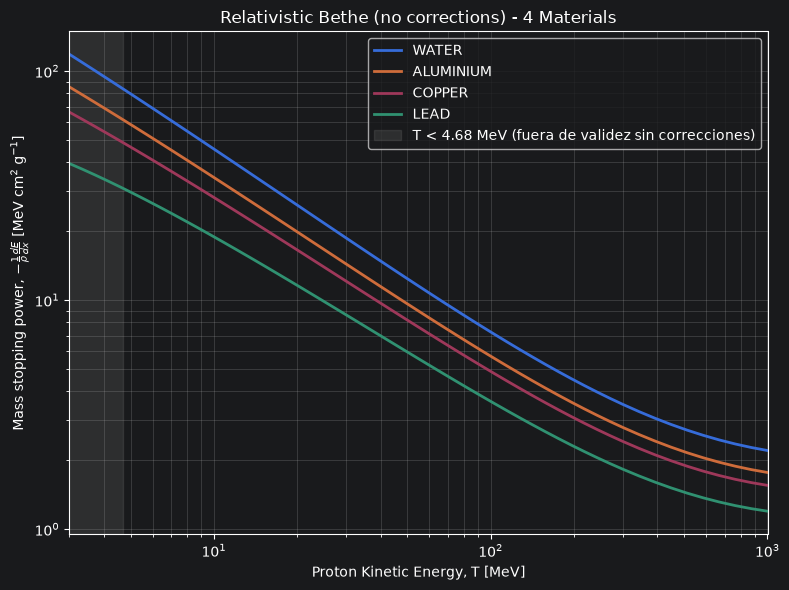

In [5]:
import numpy as np
import os
import pandas as pd
import matplotlib.pyplot as plt

OUTPUT_DIR = os.path.join(os.getcwd(), "output")

def build_energy_grid():
    """
    Energy grid: 44 log-spaced points in the clinical range of 3–300 MeV,
    with an extended margin up to 1000 MeV with 10 additional points for
    visualization purposes only.
    """
    clinical = np.logspace(np.log10(3.0), np.log10(300.0), 44)
    extension = np.logspace(np.log10(300.0), np.log10(1000.0), 10)
    return np.concatenate([clinical, extension])

def generate_all():
    os.makedirs(OUTPUT_DIR, exist_ok=True)
    energies = build_energy_grid()

    all_rows = []
    for key, mat in MATERIALS.items():
        S_mass = mass_stopping_power(energies, mat)
        S_linear = linear_stopping_power(energies, mat)
        vc = validity_check(energies)

        df = pd.DataFrame({
            "material": mat.name,
            "T_MeV": energies,
            "S_mass_MeV_cm2_g": S_mass,
            "S_linear_MeV_cm": S_linear,
            "beta": vc["beta"],
            "gamma": vc["gamma"],
            "beta_gamma": vc["beta_gamma"],
            "valid_uncorrected_bethe": vc["valid_uncorrected_bethe"],
        })

        out_path = os.path.join(OUTPUT_DIR, f"bethe_analytic_{key}.csv")
        df.to_csv(out_path, index=False)
        print(f"Written {out_path} ({len(df)} filas)")

        all_rows.append(df)

    combined = pd.concat(all_rows, ignore_index=True)
    combined_path = os.path.join(OUTPUT_DIR, "bathe_analytic_all.csv")
    combined.to_csv(combined_path, index=False)
    print(f"Written {combined_path} ({len(combined)} filas)")

    return combined

def plot_curves(combined: pd.DataFrame):
    fig, ax = plt.subplots(figsize=(8, 6))

    for key, mat in MATERIALS.items():
        sub = combined[combined["material"] == mat.name]
        ax.plot(sub["T_MeV"], sub["S_mass_MeV_cm2_g"], label=mat.name, linewidth=2)

    #   Shade the region under the validity threshold (beta*gamma < 0.1)
    ax.axvspan(0, 4.68, color="grey", alpha=0.2,
               label="T < 4.68 MeV (fuera de validez sin correcciones)")
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("Proton Kinetic Energy, T [MeV]")
    ax.set_ylabel(r"Mass stopping power, $-\frac{1}{\rho}\frac{dE}{dx}$ [MeV cm$^2$ g$^{-1}$]")
    ax.set_title("Relativistic Bethe (no corrections) - 4 Materials")
    ax.set_xlim(3, 1000)
    ax.legend()
    ax.grid(True, which="both", alpha=0.3)

    fig.tight_layout()
    out_path = os.path.join(OUTPUT_DIR, "dEdx_vs_energy.png")
    fig.savefig(out_path, dpi=300)
    print(f"Saved {out_path}")
    #plt.close(fig)

if __name__ == "__main__":
    combined = generate_all()
    plot_curves(combined)

# Stopping Power Uncertainty Propagation

## Overview

This section implements uncertainty propagation for the analyitic Bethe-Bloch stopping power, using the standard uncorrelated error-propagation formula:

$$\Delta f = \sqrt{\sum_i \left(\frac{\partial f}{\partial x_i}\Delta x_i\right)^2}$$$

where $f$ is either the mass or linear stopping power.

## Choice of Variables

$S(T)$ depends on the following physical quantities:

$$S(T) = K \cdot z^2 \cdot \frac{Z}{A} \cdot \frac{1}{\beta^2}\left[\ln\left(\frac{2m_ec^2\beta^2\gamma^2}{I}\right) - \beta^2\right]$$

We propagate uncertainty through $\{K, Z/A, m_e, I\}$ (and additionally $\rho$ for the *linear* form only, since $S_{\text{linear}} = S_{\text{mass}} \cdot \rho$). Note on the elementary charge $e$: it enters the equation only through $K = 4\pi N_A r_e^2 m_e c^2$ (with $r_e = e^2/m_ec^2$). Rather than differentiating with respect to $e$ separately -- which would require carefully separating $m_e$'s two distinct functional appearances (once inside $K$, once directly inside the logarithm) to avoid double-counting -- $K$ is treated as a single lumped constant with its own (CODATA-propagated) uncertainty. $\beta$, $\gamma$ and $z$ are treated as exact (the beam energy $T$ is assumed known; energy-spread propagation is not part of this budget).

$Z/A$ carries uncertainty through the standard atomic weight $A$ (now an explicit field on every Material, alongside $I$ and $\rho$ -- see the updated Material definitions above), rather than being treated as negligible.

## Uncertainty Sourcing

| Variable | Value | Source |
|---|---|---|
| $I$ (water) | $78(2)$ eV | *ICRU Report 90* (2016), Sec. 5.3, "Mean Excitation Energy of Liquid Water" |
| $I$ (Al) | $166(2)$ eV | *ICRU Report 49* (1993), Table 2.8, Sec. 2.5.1, "Mean Excitation Energies for Elements" |
| $I$ (Cu) | $322(10)$ eV | Same source |
| $I$ (Pb) | $823(30)$ eV | Same source |
| $m_ec^2$ | $0.510\,998\,950\,69(16)$ MeV | CODATA 2022, [physics.nist.gov/cgi-bin/cuu/Value?mec2mev](https://physics.nist.gov/cgi-bin/cuu/Value?mec2mev) |
| $K$ | $0.307075$ MeV cm$^2$/mol | Not independently tabulated; *propagated* from the same CODATA constants that define it ($N_A$ exact, $m_ec^2$ and $r_e$ known to $\sim10^{-9}$ relative) |
| $A$ (H) | $1.0080(2)$ g/mol | *IUPAC/CIAAW*, Table 2, "List of Elements in Atomic Number Order" ([iupac.qmul.ac.uk/AtWt](https://iupac.qmul.ac.uk/AtWt/)) |
| $A$ (O) | $15.999(1)$ g/mol | Same source |
| $A$ (Al) | $26.981\,5384(3)$ g/mol | Same source |
| $A$ (Cu) | $63.546(3)$ g/mol | Same source |
| $A$ (Pb) | $207.2(1.1)$ g/mol | Same source -- *note the large uncertainty: Pb's standard atomic weight was changed to an interval, $[206.14, 207.94]$, in the 2021 IUPAC revision, reflecting genuine natural isotopic variability. $207.2(1.1)$ is IUPAC's own conservative symmetric value chosen to cover that full interval -- this is *not a typo carried over from the older $207.2(1)$ figure used earlier in this notebook. |
| $\rho$ (all 4) | see Material definitions | *PubChem* Periodic Table ([pubchem.ncbi.nlm.nih.gov/ptable/density](https://pubchem.ncbi.nlm.nih.gov/ptable/density/)). PubChem does not publish a density uncertainty; a representative *0.5% ASSUMED* tolerance is used for all four materials (no uncertainty source was located for solid/liquid densities). |

*Water's $Z/A$ uncertainty* is propagated through the Bragg additivity rule directly from $\Delta A_H$ and $\Delta A_O$ above (see `_delta_ZA()` below), rather than assumed as a flat percentage.

*Key result to verify below:* $\Delta I$ dominates the uncertainty budget for water, aluminium and copper, as expected. For *lead, however, $\Delta A = 1.1$ g/mol is large enough that it is *no longer negligible -- it contributes a non-trivial fraction of the total variance, a direct consequence of Pb's unusually large natural isotopic variability (flagged by IUPAC itself). $K$ and $m_e$ remain negligible everywhere (CODATA precision, $\sim10^{-9}$ relative).

In [6]:
import sympy as sp

# Delta(m_e c^2): CODATA 2022 (NIST, https://physics.nist.gov/cgi-bin/cuu/Value?mec2mev),
# m_e c^2 = 0.510 998 950 69(16) MeV -- i.e. Delta = 1.6e-10 MeV
# (relative uncertainty ~3.1e-10).
DELTA_ELECTRON_MASS_MEV = 1.6e-10

# Delta(K): K = 4*pi*N_A*r_e^2*m_e*c^2 is not independently tabulated by
# CODATA or PDG; it is PROPAGATED from the same set of CODATA 2022
# constants that define it. N_A is EXACT (2019 SI redefinition); m_e c^2
# is known to ~3.1e-10 relative (see above) and r_e (classical electron
# radius) to ~4.6e-10 relative, giving K a relative uncertainty of order
# 1e-9 -- negligible next to Delta(I), but propagated explicitly rather
# than assumed zero.
DELTA_K_MEV_CM2_PER_MOL = 3.0e-10

In [7]:
# S(K, ZA, me, I; beta, gamma, z) = K * z^2 * ZA * (1/beta^2) *
#                                    [ ln(2*me*beta^2*gamma^2/I) - beta^2 ]
#
# beta, gamma and z are treated as EXACT for this uncertainty budget
# (T is assumed to be a known/exact input); only K, Z/A, m_e and I carry
# uncertainty, per the variable set specified for this task.

_K, _ZA, _me, _I, _beta, _gamma, _z = sp.symbols('K ZA me I beta gamma z', positive=True)

_S_expr = _K * _z**2 * _ZA * (sp.log(2 * _me * _beta**2 * _gamma**2 / _I) - _beta**2) / _beta**2

_dS_dK_expr = sp.diff(_S_expr, _K)
_dS_dZA_expr = sp.diff(_S_expr, _ZA)
_dS_dme_expr = sp.diff(_S_expr, _me)
_dS_dI_expr = sp.diff(_S_expr, _I)

_symbols_order = (_K, _ZA, _me, _I, _beta, _gamma, _z)

_dS_dK_fn = sp.lambdify(_symbols_order, _dS_dK_expr, 'numpy')
_dS_dZA_fn = sp.lambdify(_symbols_order, _dS_dZA_expr, 'numpy')
_dS_dme_fn = sp.lambdify(_symbols_order, _dS_dme_expr, 'numpy')
_dS_dI_fn = sp.lambdify(_symbols_order, _dS_dI_expr, 'numpy')

print("Symbolic partial derivatives of S(T) (mass stopping power form):")
print("     dS/dK =", _dS_dK_expr)
print("     dS/dZA =", _dS_dZA_expr)
print("     dS/dme =", _dS_dme_expr)
print("     dS/dI =", _dS_dI_expr)

Symbolic partial derivatives of S(T) (mass stopping power form):
     dS/dK = ZA*z**2*(-beta**2 + log(2*beta**2*gamma**2*me/I))/beta**2
     dS/dZA = K*z**2*(-beta**2 + log(2*beta**2*gamma**2*me/I))/beta**2
     dS/dme = K*ZA*z**2/(beta**2*me)
     dS/dI = -K*ZA*z**2/(I*beta**2)


In [8]:
def _delta_ZA(material: Material) -> float:
    """
    Absolute uncertainty on Z/A for `material`, in mol/g, propagated
    from the atomic-weight uncertainty Delta(A) (IUPAC/CIAAW).

    For pure elements: Z/A = Z / A_molar, so d(Z/A)/dA_molar =
    -Z/A_molar^2 = -(Z/A)/A_molar, giving
    Delta(Z/A) = (Z/A)/A_molar * Delta(A_molar).

    For water (a compound, material.A_g_mol is None): Z/A is computed
    via the Bragg additivity rule from the H and O atomic weights, so
    the uncertainty is propagated through BOTH constituent elements:

        Z/A = w_H*(Z_H/A_H) + w_O*(Z_O/A_O)
        Delta(Z/A) = sqrt( (w_H*Z_H/A_H^2 * Delta(A_H))^2
                          + (w_O*Z_O/A_O^2 * Delta(A_O))^2 )

    with w_H, w_O taken as exact (NIST STAR mass fractions).
    """
    if material.A_g_mol is None:
        # Water: propagate through the Bragg-rule constituents directly.
        dZA_dAH = -WATER_W_H * WATER_Z_H / WATER_A_H**2
        dZA_dAO = -WATER_W_O * WATER_Z_O / WATER_A_O**2
        return np.sqrt((dZA_dAH * WATER_DELTA_A_H) ** 2
                        + (dZA_dAO * WATER_DELTA_A_O) ** 2)
    return (material.Z_over_A / material.A_g_mol) * material.Delta_A_g_mol


def propagate_mass_stopping_power_uncertainty(T_MeV, material_key: str, z=1,
                                                particle_mass_MeV=PROTON_MASS_MEV,
                                                return_breakdown=False):
    """
    Uncertainty Delta(S) on the mass stopping power S(T) [MeV cm^2/g],
    via the standard uncorrelated error-propagation formula:

        Delta(f) = sqrt( sum_i (df/dx_i * Delta(x_i))^2 )

    with x_i in {K, Z/A, m_e, I}. Delta(I) and Delta(Z/A) (via Delta(A))
    are read directly from the `Material` object -- see its definition
    for sourcing (ICRU 90 / ICRU 49 for I, IUPAC/CIAAW for A).

    Parameters
    ----------
    :param T_MeV: Kinetic energy in MeV (array-like)
    :param material_key: key into MATERIALS
    :param z: Projectile charge in e units (float)
    :param particle_mass_MeV: Particle mass in MeV (float)
    :param return_breakdown: if True, also return the per-source terms

    Returns
    -------
    :return: Delta_S (np.ndarray, MeV cm^2/g), and optionally a dict
        with the individual {K, ZA, me, I} contributions (same units;
        these combine in QUADRATURE, not by direct summation, to give
        Delta_S).
    """
    material = MATERIALS[material_key]
    T_MeV = np.asarray(T_MeV, dtype=float)
    beta, gamma = beta_gamma_from_kinetic_energy(T_MeV, particle_mass_MeV)

    K_val = K_MEV_CM2_PER_MOL
    ZA_val = material.Z_over_A
    me_val = ELECTRON_MASS_MEV
    I_val = material.I_eV * EV_TO_MEV

    dK = DELTA_K_MEV_CM2_PER_MOL
    dZA = _delta_ZA(material)
    dme = DELTA_ELECTRON_MASS_MEV
    dI = material.Delta_I_eV * EV_TO_MEV

    term_K = _dS_dK_fn(K_val, ZA_val, me_val, I_val, beta, gamma, z) * dK
    term_ZA = _dS_dZA_fn(K_val, ZA_val, me_val, I_val, beta, gamma, z) * dZA
    term_me = _dS_dme_fn(K_val, ZA_val, me_val, I_val, beta, gamma, z) * dme
    term_I = _dS_dI_fn(K_val, ZA_val, me_val, I_val, beta, gamma, z) * dI

    Delta_S = np.sqrt(term_K**2 + term_ZA**2 + term_me**2 + term_I**2)

    if return_breakdown:
        return Delta_S, {"K": term_K, "ZA": term_ZA, "me": term_me, "I": term_I}
    return Delta_S


def propagate_linear_stopping_power_uncertainty(T_MeV, material_key: str, z=1,
                                                   particle_mass_MeV=PROTON_MASS_MEV):
    """
    Uncertainty Delta(S_linear) on the LINEAR stopping power [MeV/cm].

    Since S_linear = S_mass * rho, and rho is uncorrelated with the
    mass-stopping-power sources (K, Z/A, m_e, I), the product rule gives:

        Delta(S_linear) = sqrt( (rho * Delta(S_mass))^2
                                 + (S_mass * Delta(rho))^2 )

    Delta(rho) is read directly from the `Material` object (PubChem
    central value, 0.5% ASSUMED uncertainty -- see Material definition).
    """
    material = MATERIALS[material_key]
    T_MeV = np.asarray(T_MeV, dtype=float)

    S_mass = mass_stopping_power(T_MeV, material, z, particle_mass_MeV)
    Delta_S_mass = propagate_mass_stopping_power_uncertainty(
        T_MeV, material_key, z, particle_mass_MeV)

    rho = material.rho_g_cm3
    d_rho = material.Delta_rho_g_cm3

    return np.sqrt((rho * Delta_S_mass) ** 2 + (S_mass * d_rho) ** 2)

if __name__ == "__main__":
    T_test = 100.0
    S = mass_stopping_power(T_test, WATER)
    dS, breakdown = propagate_mass_stopping_power_uncertainty(
        T_test, "water", return_breakdown=True)

    print(f"Proton {T_test} MeV in water:")
    print(f"  S       = {S:.4f} MeV cm^2/g")
    print(f"  Delta S = {dS:.4f} MeV cm^2/g  ({100*dS/S:.2f}% relative)")
    print("  Variance-fraction breakdown (term^2 / Delta_S^2, since terms")
    print("  combine in quadrature -- NOT term/Delta_S):")
    total_var = sum(float(v) ** 2 for v in breakdown.values())
    for k, v in breakdown.items():
        print(f"    {k:4s}: {float(v):+.6f} MeV cm^2/g   "
              f"({100 * float(v)**2/total_var:.2f}% of total variance)")
    print("  -> Delta(I) should dominate almost completely; K and m_e are "
          "expected to be negligible (both derive from CODATA constants "
          "known to ~1e-9 relative precision).")

Proton 100.0 MeV in water:
  S       = 7.2545 MeV cm^2/g
  Delta S = 0.0238 MeV cm^2/g  (0.33% relative)
  Variance-fraction breakdown (term^2 / Delta_S^2, since terms
  combine in quadrature -- NOT term/Delta_S):
    K   : +0.000000 MeV cm^2/g   (0.00% of total variance)
    ZA  : +0.000463 MeV cm^2/g   (0.04% of total variance)
    me  : +0.000000 MeV cm^2/g   (0.00% of total variance)
    I   : -0.023837 MeV cm^2/g   (99.96% of total variance)
  -> Delta(I) should dominate almost completely; K and m_e are expected to be negligible (both derive from CODATA constants known to ~1e-9 relative precision).


## Uncertainty Propagation Tests

**`test_negligible_K_and_me_contributions`** verifies that $K$ and $m_e$ -- both known to ~$10^{-9}$ relative precision from CODATA -- contribute less than 0.01% of the total variance. **`test_I_dominates_uncertainty_budget`** confirms $\Delta I$ is the single largest contributor for all four materials (note: for lead, $\Delta A$ is a substantial secondary contributor -- see discussion above -- so this test checks "largest", not ">50%"). **`test_relative_uncertainty_in_reasonable_range`** checks $\Delta S/S$ stays within a physically sane band (<5%) across the clinical range. **`test_relative_uncertainty_grows_at_lower_energy`** verifies the expected monotonic growth of relative uncertainty as energy decreases. **`test_linear_uncertainty_at_least_density_scaled_mass_uncertainty`** checks the quadrature-sum triangle inequality for the linear form. **`test_I_term_scales_linearly_with_delta_I`** is a pure linearity check on the propagation math, applied directly to the lambdified derivative. **`test_water_5eV_shift_matches_literature_order_of_magnitude`** cross-validates against Kumazaki et al. (2007), who report a 0.8-1.2% stopping-power change for a 75→80 eV shift in water's $I$-value; built with two explicit `Material` instances at $I=75$ and $I=80$ eV so the check is independent of whichever $I$-value is adopted as WATER's current central value.


In [9]:
def test_negligible_K_and_me_contributions():
    # K and m_e derive from CODATA constants known to ~1e-9 relative
    # precision; their variance contribution should be utterly negligible
    # (< 0.01% of the total variance) at any representative energy point.
    _, breakdown = propagate_mass_stopping_power_uncertainty(
        100.0, "water", return_breakdown=True)
    total_var = sum(float(v) ** 2 for v in breakdown.values())
    for key in ("K", "me"):
        var_frac = float(breakdown[key]) ** 2 / total_var
        assert var_frac < 1e-4, f"{key} contributes {var_frac:.2e} of variance, expected negligible"


def test_I_dominates_uncertainty_budget():
    # Delta(I) should be the dominant source of uncertainty for all four
    # materials at a representative clinical energy -- though for lead,
    # Delta(A)=1.1 g/mol (IUPAC's conservative interval-covering value)
    # is no longer negligible, so we only require I to be the SINGLE
    # largest contributor, not necessarily >50% for every material.
    for key in MATERIALS:
        _, breakdown = propagate_mass_stopping_power_uncertainty(
            100.0, key, return_breakdown=True)
        var_fracs = {k: float(v) ** 2 for k, v in breakdown.items()}
        dominant = max(var_fracs, key=var_fracs.get)
        assert dominant == "I", f"{key}: expected I to dominate, got {dominant}"


def test_relative_uncertainty_in_reasonable_range():
    # Across the clinical range (3-300 MeV), the relative uncertainty on
    # S should stay within a physically reasonable band (a few percent).
    energies = np.linspace(3.0, 300.0, 20)
    for key in MATERIALS:
        S = mass_stopping_power(energies, MATERIALS[key])
        dS = propagate_mass_stopping_power_uncertainty(energies, key)
        rel = dS / S
        assert np.all(rel > 0), f"{key}: relative uncertainty should be positive"
        assert np.all(rel < 0.05), f"{key}: relative uncertainty exceeds 5%, check budget"


def test_relative_uncertainty_grows_at_lower_energy():
    # Uncertainty from Delta(I) is amplified as the log-argument bracket
    # shrinks toward the low-energy end of validity; relative uncertainty
    # should be monotonically non-increasing with energy in 3-300 MeV.
    energies = np.linspace(3.0, 300.0, 30)
    S = mass_stopping_power(energies, WATER)
    dS = propagate_mass_stopping_power_uncertainty(energies, "water")
    rel = dS / S
    assert np.all(np.diff(rel) <= 0), "relative uncertainty should decrease as energy increases"


def test_linear_uncertainty_at_least_density_scaled_mass_uncertainty():
    # Delta(S_linear) = sqrt((rho*Delta(S_mass))^2 + (S_mass*Delta(rho))^2)
    # must always be >= rho*Delta(S_mass) (triangle inequality on the
    # quadrature sum), with equality only if Delta(rho) = 0.
    T = 100.0
    for key in MATERIALS:
        material = MATERIALS[key]
        dS_mass = propagate_mass_stopping_power_uncertainty(T, key)
        dS_linear = propagate_linear_stopping_power_uncertainty(T, key)
        assert dS_linear >= material.rho_g_cm3 * dS_mass - 1e-12


def test_I_term_scales_linearly_with_delta_I():
    # Pure linearity check on the propagation math: term_I = dS/dI * Delta(I),
    # so doubling Delta(I) must exactly double term_I. Tested directly on
    # the lambdified derivative (rather than mutating the frozen Material
    # dataclass) since Delta_I_eV is now a first-class Material field.
    material = COPPER
    beta, gamma = beta_gamma_from_kinetic_energy(100.0, PROTON_MASS_MEV)
    deriv = _dS_dI_fn(K_MEV_CM2_PER_MOL, material.Z_over_A, ELECTRON_MASS_MEV,
                       material.I_eV * EV_TO_MEV, beta, gamma, 1)
    term_1x = deriv * (material.Delta_I_eV * EV_TO_MEV)
    term_2x = deriv * (2 * material.Delta_I_eV * EV_TO_MEV)
    ratio = float(term_2x) / float(term_1x)
    assert np.isclose(ratio, 2.0, rtol=1e-10), f"expected exactly 2x scaling, got {ratio:.6f}"


def test_water_5eV_shift_matches_literature_order_of_magnitude():
    # Kumazaki et al. (2007): a 75 -> 80 eV shift in water's I-value
    # produces a 0.8-1.2% change in stopping power over 10-250 MeV.
    # Built explicitly at I=75 and I=80 here (independent of whichever
    # I-value is currently adopted as WATER's central value) so this
    # check remains a fixed, source-independent cross-validation.
    T = 100.0
    water_75 = Material(name="WATER_75eV", Z_over_A=WATER.Z_over_A,
                         I_eV=75.0, Delta_I_eV=0.0, rho_g_cm3=WATER.rho_g_cm3,
                         Delta_rho_g_cm3=0.0, A_g_mol=None, Delta_A_g_mol=None,
                         matno="276")
    water_80 = Material(name="WATER_80eV", Z_over_A=WATER.Z_over_A,
                         I_eV=80.0, Delta_I_eV=0.0, rho_g_cm3=WATER.rho_g_cm3,
                         Delta_rho_g_cm3=0.0, A_g_mol=None, Delta_A_g_mol=None,
                         matno="276")
    S_75 = mass_stopping_power(T, water_75)
    S_80 = mass_stopping_power(T, water_80)
    finite_diff_pct = 100 * abs(S_80 - S_75) / S_75
    assert 0.5 < finite_diff_pct < 2.0, (
        f"5 eV shift gives {finite_diff_pct:.2f}%, expected ~0.8-1.2% per literature")


def _run_uncertainty_tests():
    tests = [
        test_negligible_K_and_me_contributions,
        test_I_dominates_uncertainty_budget,
        test_relative_uncertainty_in_reasonable_range,
        test_relative_uncertainty_grows_at_lower_energy,
        test_linear_uncertainty_at_least_density_scaled_mass_uncertainty,
        test_I_term_scales_linearly_with_delta_I,
        test_water_5eV_shift_matches_literature_order_of_magnitude,
    ]
    n_ok = 0
    for t in tests:
        try:
            t()
            print(f"OK   {t.__name__}")
            n_ok += 1
        except AssertionError as e:
            print(f"FAIL {t.__name__}: {e}")
    print(f"{n_ok}/{len(tests)} tests passed")


if __name__ == "__main__":
    _run_uncertainty_tests()


OK   test_negligible_K_and_me_contributions
OK   test_I_dominates_uncertainty_budget
OK   test_relative_uncertainty_in_reasonable_range
OK   test_relative_uncertainty_grows_at_lower_energy
OK   test_linear_uncertainty_at_least_density_scaled_mass_uncertainty
OK   test_I_term_scales_linearly_with_delta_I
OK   test_water_5eV_shift_matches_literature_order_of_magnitude
7/7 tests passed


## Uncertainty-Augmented Output: CSV + Plots

Regenerates the dE/dx dataset over the same energy grid as `generate_all()`, adding `Delta_S_mass_MeV_cm2_g`, `S_mass_relative_uncertainty_pct`, `Delta_S_linear_MeV_cm`, and `S_linear_relative_uncertainty_pct` columns.

### Output Files

| File | Description |
|---|---|
| `output/bethe_analytic_with_uncertainty_<material>.csv` | Per-material data with uncertainty columns |
| `output/bethe_analytic_with_uncertainty_all.csv` | Combined dataset |
| `output/dEdx_with_uncertainty.png` | Two-panel figure: (left) $S(T)$ with $\pm1\sigma$ shaded band, (right) relative uncertainty (%) vs. energy — mirrors the two-panel layout already used in `compare_stopping.py` (Geant4 vs. PSTAR) for visual consistency across the project.

**Note on filenames:** these use the `bethe_analytic_...` prefix (corrected spelling) rather than the `bathe_analytic_...` prefix used in the cell above — that appears to be an unintentional typo in the existing output filenames. Worth a quick rename for consistency before this goes in the repo, but left untouched here since it wasn't part of this task.


Written /home/yorch/bethe-bloch-geant4-validation/python/analytic/output/bethe_analytic_with_uncertainty_water.csv (54 rows)
Written /home/yorch/bethe-bloch-geant4-validation/python/analytic/output/bethe_analytic_with_uncertainty_aluminium.csv (54 rows)
Written /home/yorch/bethe-bloch-geant4-validation/python/analytic/output/bethe_analytic_with_uncertainty_copper.csv (54 rows)
Written /home/yorch/bethe-bloch-geant4-validation/python/analytic/output/bethe_analytic_with_uncertainty_lead.csv (54 rows)
Written /home/yorch/bethe-bloch-geant4-validation/python/analytic/output/bethe_analytic_with_uncertainty_all.csv (216 rows)
Saved /home/yorch/bethe-bloch-geant4-validation/python/analytic/output/dEdx_with_uncertainty.png

Uncertainty budget summary at T=100 MeV (variance fraction, %):
Material           K      ZA      me       I   Total rel.%
WATER          0.000   0.038   0.000  99.962         0.329
ALUMINIUM      0.000   0.000   0.000 100.000         0.171
COPPER         0.000   0.009   0.

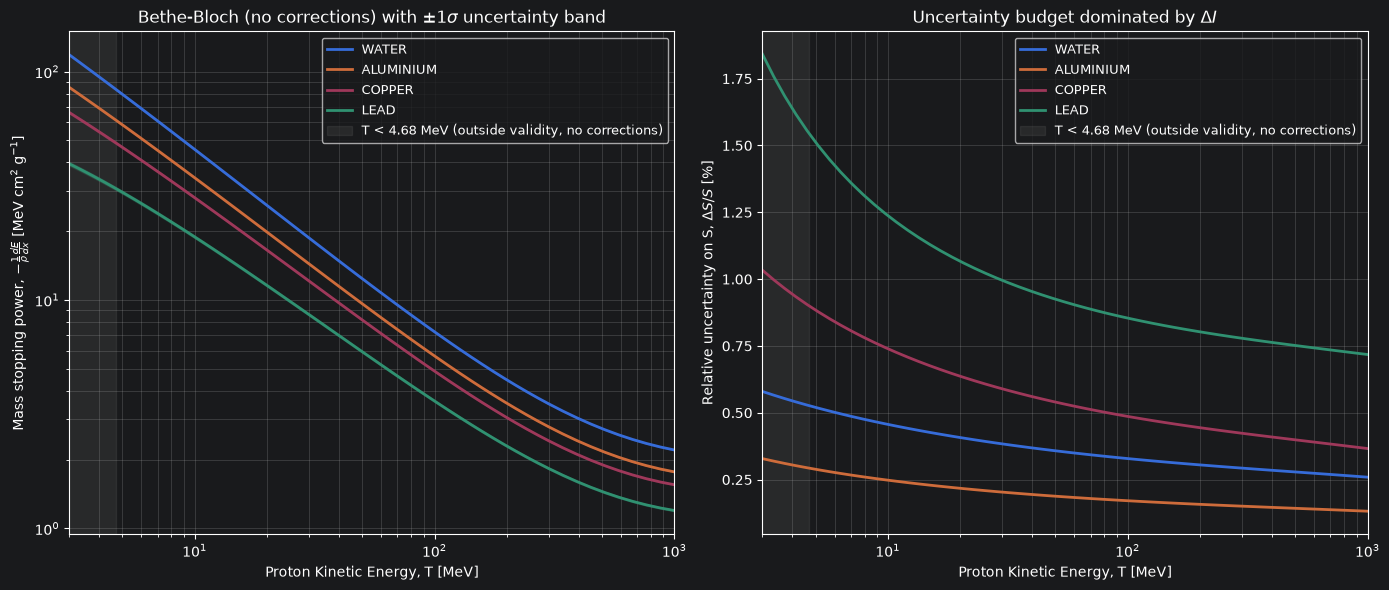

In [12]:
def generate_all_with_uncertainty():
    """
    Re-generates the dE/dx dataset (same energy grid as generate_all())
    but with Delta(S_mass) and Delta(S_linear) columns added, propagated
    per propagate_mass_stopping_power_uncertainty() /
    propagate_linear_stopping_power_uncertainty().
    """
    os.makedirs(OUTPUT_DIR, exist_ok=True)
    energies = build_energy_grid()

    all_rows = []
    for key, mat in MATERIALS.items():
        S_mass = mass_stopping_power(energies, mat)
        S_linear = linear_stopping_power(energies, mat)
        dS_mass = propagate_mass_stopping_power_uncertainty(energies, key)
        dS_linear = propagate_linear_stopping_power_uncertainty(energies, key)
        vc = validity_check(energies)

        df = pd.DataFrame({
            "material": mat.name,
            "T_MeV": energies,
            "S_mass_MeV_cm2_g": S_mass,
            "Delta_S_mass_MeV_cm2_g": dS_mass,
            "S_mass_relative_uncertainty_pct": 100 * dS_mass / S_mass,
            "S_linear_MeV_cm": S_linear,
            "Delta_S_linear_MeV_cm": dS_linear,
            "S_linear_relative_uncertainty_pct": 100 * dS_linear / S_linear,
            "beta": vc["beta"],
            "gamma": vc["gamma"],
            "beta_gamma": vc["beta_gamma"],
            "valid_uncorrected_bethe": vc["valid_uncorrected_bethe"],
        })

        out_path = os.path.join(OUTPUT_DIR, f"bethe_analytic_with_uncertainty_{key}.csv")
        df.to_csv(out_path, index=False)
        print(f"Written {out_path} ({len(df)} rows)")

        all_rows.append(df)

    combined = pd.concat(all_rows, ignore_index=True)
    combined_path = os.path.join(OUTPUT_DIR, "bethe_analytic_with_uncertainty_all.csv")
    combined.to_csv(combined_path, index=False)
    print(f"Written {combined_path} ({len(combined)} rows)")

    return combined


def plot_curves_with_uncertainty(combined: pd.DataFrame):
    """
    Two-panel figure: (left) S(T) with a shaded +/-1 sigma band per
    material, (right) relative uncertainty (%) vs energy per material.
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

    for key, mat in MATERIALS.items():
        sub = combined[combined["material"] == mat.name]
        T = sub["T_MeV"]
        S = sub["S_mass_MeV_cm2_g"]
        dS = sub["Delta_S_mass_MeV_cm2_g"]
        rel = sub["S_mass_relative_uncertainty_pct"]

        line, = ax1.plot(T, S, label=mat.name, linewidth=2)
        ax1.fill_between(T, S - dS, S + dS, color=line.get_color(), alpha=0.25)

        ax2.plot(T, rel, label=mat.name, linewidth=2, color=line.get_color())

    for ax in (ax1, ax2):
        ax.axvspan(0, 4.68, color="grey", alpha=0.15,
                   label="T < 4.68 MeV (outside validity, no corrections)")
        ax.set_xscale("log")
        ax.set_xlim(3, 1000)
        ax.set_xlabel("Proton Kinetic Energy, T [MeV]")
        ax.grid(True, which="both", alpha=0.3)

    ax1.set_yscale("log")
    ax1.set_ylabel(r"Mass stopping power, $-\frac{1}{\rho}\frac{dE}{dx}$ [MeV cm$^2$ g$^{-1}$]")
    ax1.set_title("Bethe-Bloch (no corrections) with $\\pm1\\sigma$ uncertainty band")
    ax1.legend(fontsize=9)

    ax2.set_ylabel("Relative uncertainty on S, $\\Delta S / S$ [%]")
    ax2.set_title("Uncertainty budget dominated by $\\Delta I$")
    ax2.legend(fontsize=9)

    fig.tight_layout()
    out_path = os.path.join(OUTPUT_DIR, "dEdx_with_uncertainty.png")
    fig.savefig(out_path, dpi=300)
    print(f"Saved {out_path}")


if __name__ == "__main__":
    combined_with_uncertainty = generate_all_with_uncertainty()
    plot_curves_with_uncertainty(combined_with_uncertainty)

    print("\nUncertainty budget summary at T=100 MeV (variance fraction, %):")
    print(f"{'Material':<12}{'K':>8}{'ZA':>8}{'me':>8}{'I':>8}{'Total rel.%':>14}")
    for key, mat in MATERIALS.items():
        S = mass_stopping_power(100.0, mat)
        dS, breakdown = propagate_mass_stopping_power_uncertainty(
            100.0, key, return_breakdown=True)
        total_var = sum(float(v) ** 2 for v in breakdown.values())
        fracs = {k: 100 * float(v) ** 2 / total_var for k, v in breakdown.items()}
        print(f"{mat.name:<12}{fracs['K']:>8.3f}{fracs['ZA']:>8.3f}"
              f"{fracs['me']:>8.3f}{fracs['I']:>8.3f}{100*dS/S:>14.3f}")